In [ ]:
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from typing import List, Tuple, Dict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sentence_transformers import SentenceTransformer
from IPython.display import display, HTML
from google.colab import drive

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})

In [ ]:
file_path = '/content/drive/MyDrive/wos_data/retract_class.csv'

In [ ]:
# =========================================
# Step 1: Load and preprocess the data
# =========================================
print("Loading data...")
df = pd.read_csv(file_path)


df['text'] = df['Article Title'].fillna('')

# Preprocess text
def preprocess_text(text):
    if pd.isna(text):
        return ''
    return str(text).lower()

df['processed_text'] = df['text'].apply(preprocess_text)

if 'retracted' not in df.columns:
    df['retracted'] = 'no'  # Default to not retracted
if 'Impact Factor' not in df.columns:
    df['Impact Factor'] = 1.0  # Default impact factor
if 'Cited' not in df.columns:
    df['Cited'] = 0  # Default citation count
if 'altmetric_score' not in df.columns:
    df['altmetric_score'] = 0  # Default altmetric score

# Clean Impact Factor
df['Impact Factor'] = df['Impact Factor'].replace('<0.1', '0')
df['Impact Factor'] = pd.to_numeric(df['Impact Factor'], errors='coerce').fillna(0)

print(f"Dataset loaded with {df.shape[0]} articles and {df.shape[1]} columns")
print(f"Sample columns: {', '.join(df.columns[:5])}")

Loading data...
Dataset loaded with 16052 articles and 9 columns
Sample columns: Article Title, Cited, Impact Factor, altmetric_score, DOI


In [ ]:
# =========================================
# Step 2: Initialize BERT model
# =========================================
print("\nInitializing BERT model...")
model = SentenceTransformer('distilbert-base-nli-mean-tokens')
print("BERT model initialized successfully")

# =========================================
# Step 3: Train Random Forest classifier
# =========================================
print("\nTraining Random Forest classifier...")t
X = df[['Cited', 'altmetric_score', 'Impact Factor']]
y = (df['retracted'] == 'yes').astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_scaled, y)

# Print feature importance
importance = pd.DataFrame({
    'Feature': ['Citations', 'Altmetric Score', 'Impact Factor'],
    'Importance': rf_model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance)


Initializing BERT model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BERT model initialized successfully

Training Random Forest classifier...

Feature Importance:
           Feature  Importance
0        Citations    0.470337
1  Altmetric Score    0.345117
2    Impact Factor    0.184547


In [ ]:
# =========================================
# Step 4: Define the complete search function
# =========================================
def search_academic_articles(query, top_k=10, alpha=0.5):
    """
    Complete academic search function implementing the three-layer architecture.

    Args:
        query: User search query
        top_k: Number of top results to return
        alpha: Weight between relevance and trustworthiness (1 = only relevance)

    Returns:
        Tuple of (ranked_results, eliminated_papers)
    """
    print(f"\nSearching for: '{query}'")
    start_time = time.time()

    # ==============================================
    # Layer 1: BERT Embedding and Similarity Comparison
    # ==============================================
    print("\nLayer 1: BERT Embedding and Similarity Comparison")

    # Generate embeddings
    print("  Generating query embedding...")
    query_embedding = model.encode([query])

    print("  Generating document embeddings...")
    doc_embeddings = model.encode(df['processed_text'].tolist())

    # Calculate similarity
    print("  Calculating cosine similarity...")
    similarities = cosine_similarity(query_embedding, doc_embeddings).flatten()

    # Select top 10% most similar documents
    threshold = max(int(len(similarities) * 0.1), 20)  # At least 20 documents
    top_indices = similarities.argsort()[-threshold:][::-1]
    top_similar_df = df.iloc[top_indices].copy()
    top_similar_df['similarity_score'] = similarities[top_indices]

    print(f"  Found {len(top_similar_df)} articles with high similarity")

    # ==============================================
    # Layer 2: Elimination of Problematic Articles
    # ==============================================
    print("\nLayer 2: Elimination of Problematic Articles")

    X_top = top_similar_df[['Cited', 'altmetric_score', 'Impact Factor']]
    X_top_scaled = scaler.transform(X_top)

    # Predict probability of being problematic
    print("  Classifying articles...")
    top_similar_df['problematic_prob'] = rf_model.predict_proba(X_top_scaled)[:, 1]

    # Filter using a threshold
    threshold = 0.3  # Probability threshold
    top_similar_df['is_problematic'] = top_similar_df['problematic_prob'] > threshold

    # Split into trusted and eliminated
    trusted_df = top_similar_df[~top_similar_df['is_problematic']].copy()
    eliminated_df = top_similar_df[top_similar_df['is_problematic']].copy()

    print(f"  Retained {len(trusted_df)} trusted articles")
    print(f"  Eliminated {len(eliminated_df)} potentially problematic articles")

    # ==============================================
    # Layer 3: Final Result Ranking
    # ==============================================
    print("\nLayer 3: Final Result Ranking")

    if not trusted_df.empty:
        # Calculate trustworthiness score components
        # 1. Citation rank
        trusted_df['citation_rank'] = trusted_df['Cited'].rank(pct=True)

        # 2. Relative citation impact
        mean_citations = max(trusted_df['Cited'].mean(), 1)
        trusted_df['relative_citation_impact'] = trusted_df['Cited'] / mean_citations
        trusted_df['relative_citation_impact'] = trusted_df['relative_citation_impact'].clip(0, 5)

        # 3. Impact factor rank
        trusted_df['impact_factor_rank'] = trusted_df['Impact Factor'].rank(pct=True)

        # Calculate trustworthiness score using weights from research
        trusted_df['trustworthiness_score'] = (
            0.25 * trusted_df['citation_rank'] +
            0.23 * trusted_df['relative_citation_impact'] / 5 +
            0.19 * trusted_df['impact_factor_rank']
        )
        trusted_df['trustworthiness_score'] = trusted_df['trustworthiness_score'] / 0.67

        # Calculate final score with alpha parameter
        trusted_df['final_score'] = alpha * trusted_df['similarity_score'] + (1 - alpha) * trusted_df['trustworthiness_score']

        # Sort by final score
        ranked_df = trusted_df.sort_values('final_score', ascending=False)
    else:
        ranked_df = trusted_df  # Empty DataFrame

    end_time = time.time()
    print(f"\nSearch completed in {end_time - start_time:.2f} seconds")

    # Return top-k results and examples of eliminated papers
    return ranked_df.head(top_k), eliminated_df.head(5)


In [ ]:
# =========================================
# Step 5: Display results function
# =========================================
def display_search_results(ranked_results, eliminated_examples):
    """
    Display search results in a formatted way.

    Args:
        ranked_results: DataFrame of ranked search results
        eliminated_examples: DataFrame of eliminated articles
    """
    if ranked_results.empty:
        print("No results found.")
        return

    # Display top ranked results
    print("\n===== Top Ranked Results =====")
    for i, (_, article) in enumerate(ranked_results.iterrows(), 1):
        print(f"\n{i}. {article['Article Title']}")
        print(f"   Relevance Score: {article['similarity_score']:.4f}")
        print(f"   Trustworthiness Score: {article['trustworthiness_score']:.4f}")
        print(f"   Final Score: {article['final_score']:.4f}")
        print(f"   Citations: {article['Cited']}")
        print(f"   Impact Factor: {article['Impact Factor']}")
        if 'DOI' in article and not pd.isna(article['DOI']):
            print(f"   DOI: {article['DOI']}")

    # Display eliminated examples
    if not eliminated_examples.empty:
        print("\n\n===== Examples of Eliminated Articles =====")
        for i, (_, article) in enumerate(eliminated_examples.iterrows(), 1):
            print(f"\n{i}. {article['Article Title']}")
            print(f"   Relevance Score: {article['similarity_score']:.4f}")
            print(f"   Problematic Probability: {article['problematic_prob']:.4f}")
            print(f"   Citations: {article['Cited']}")
            print(f"   Impact Factor: {article['Impact Factor']}")

In [ ]:
# =========================================
# Step 6: Visualize results function
# =========================================
def visualize_search_results(ranked_results, eliminated_examples):
    """
    Create visualizations of search results.

    Args:
        ranked_results: DataFrame of ranked search results
        eliminated_examples: DataFrame of eliminated articles
    """
    if ranked_results.empty:
        print("No results to visualize.")
        return

    # Create a 2x2 grid of plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Scatter plot: Relevance vs. Trustworthiness
    ax1 = axes[0, 0]
    scatter = ax1.scatter(
        ranked_results['similarity_score'],
        ranked_results['trustworthiness_score'],
        c=ranked_results['final_score'],
        cmap='viridis',
        s=100,
        alpha=0.7
    )
    ax1.set_xlabel('Relevance Score')
    ax1.set_ylabel('Trustworthiness Score')
    ax1.set_title('Relevance vs. Trustworthiness')
    fig.colorbar(scatter, ax=ax1, label='Final Score')

    # 2. Bar chart: Top articles by final score
    ax2 = axes[0, 1]
    top10 = ranked_results.head(10).copy()
    top10['short_title'] = top10['Article Title'].apply(lambda x: x[:30] + '...' if len(x) > 30 else x)
    top10 = top10.sort_values('final_score')
    ax2.barh(top10['short_title'], top10['final_score'], color='skyblue')
    ax2.set_xlabel('Final Score')
    ax2.set_title('Top 10 Articles by Final Score')

    # 3. Scatter plot: Citations vs. Impact Factor
    ax3 = axes[1, 0]
    ax3.scatter(
        ranked_results['Impact Factor'],
        ranked_results['Cited'],
        c=ranked_results['trustworthiness_score'],
        cmap='plasma',
        s=100,
        alpha=0.7
    )
    if not eliminated_examples.empty:
        ax3.scatter(
            eliminated_examples['Impact Factor'],
            eliminated_examples['Cited'],
            color='red',
            marker='x',
            s=100,
            label='Eliminated'
        )
    ax3.set_xlabel('Impact Factor')
    ax3.set_ylabel('Citations')
    ax3.set_title('Citations vs. Impact Factor')
    ax3.legend()

    # 4. Stacked bar: Component contributions to score
    ax4 = axes[1, 1]
    top5 = ranked_results.head(5).copy()
    top5['short_title'] = top5['Article Title'].apply(lambda x: x[:20] + '...' if len(x) > 20 else x)

    relevance_contrib = top5['similarity_score'] * 0.5  # Assuming alpha = 0.5
    trust_contrib = top5['trustworthiness_score'] * 0.5  # Assuming alpha = 0.5

    x = np.arange(len(top5))
    width = 0.35

    ax4.bar(x, relevance_contrib, width, label='Relevance Contribution')
    ax4.bar(x, trust_contrib, width, bottom=relevance_contrib, label='Trustworthiness Contribution')

    ax4.set_ylabel('Score Contribution')
    ax4.set_title('Component Contributions to Final Score')
    ax4.set_xticks(x)
    ax4.set_xticklabels(top5['short_title'], rotation=45, ha='right')
    ax4.legend()

    plt.tight_layout()
    plt.show()



Searching for: 'climate change effects'

Layer 1: BERT Embedding and Similarity Comparison
  Generating query embedding...
  Generating document embeddings...
  Calculating cosine similarity...
  Found 1605 articles with high similarity

Layer 2: Elimination of Problematic Articles
  Classifying articles...
  Retained 959 trusted articles
  Eliminated 646 potentially problematic articles

Layer 3: Final Result Ranking

Search completed in 5.27 seconds

===== Top Ranked Results =====

1. The Dynamics of Photosynthesis
   Relevance Score: 0.6049
   Trustworthiness Score: 0.9690
   Final Score: 0.7869
   Citations: 583.0
   Impact Factor: 8.7
   DOI: 10.1146/annurev.genet.42.110807.091452

2. Time series regression studies in environmental epidemiology
   Relevance Score: 0.6148
   Trustworthiness Score: 0.9452
   Final Score: 0.7800
   Citations: 789.0
   Impact Factor: 6.4
   DOI: 10.1093/ije/dyt092

3. Environmental Sensor Networks: A revolution in the earth system science?
   Relevan

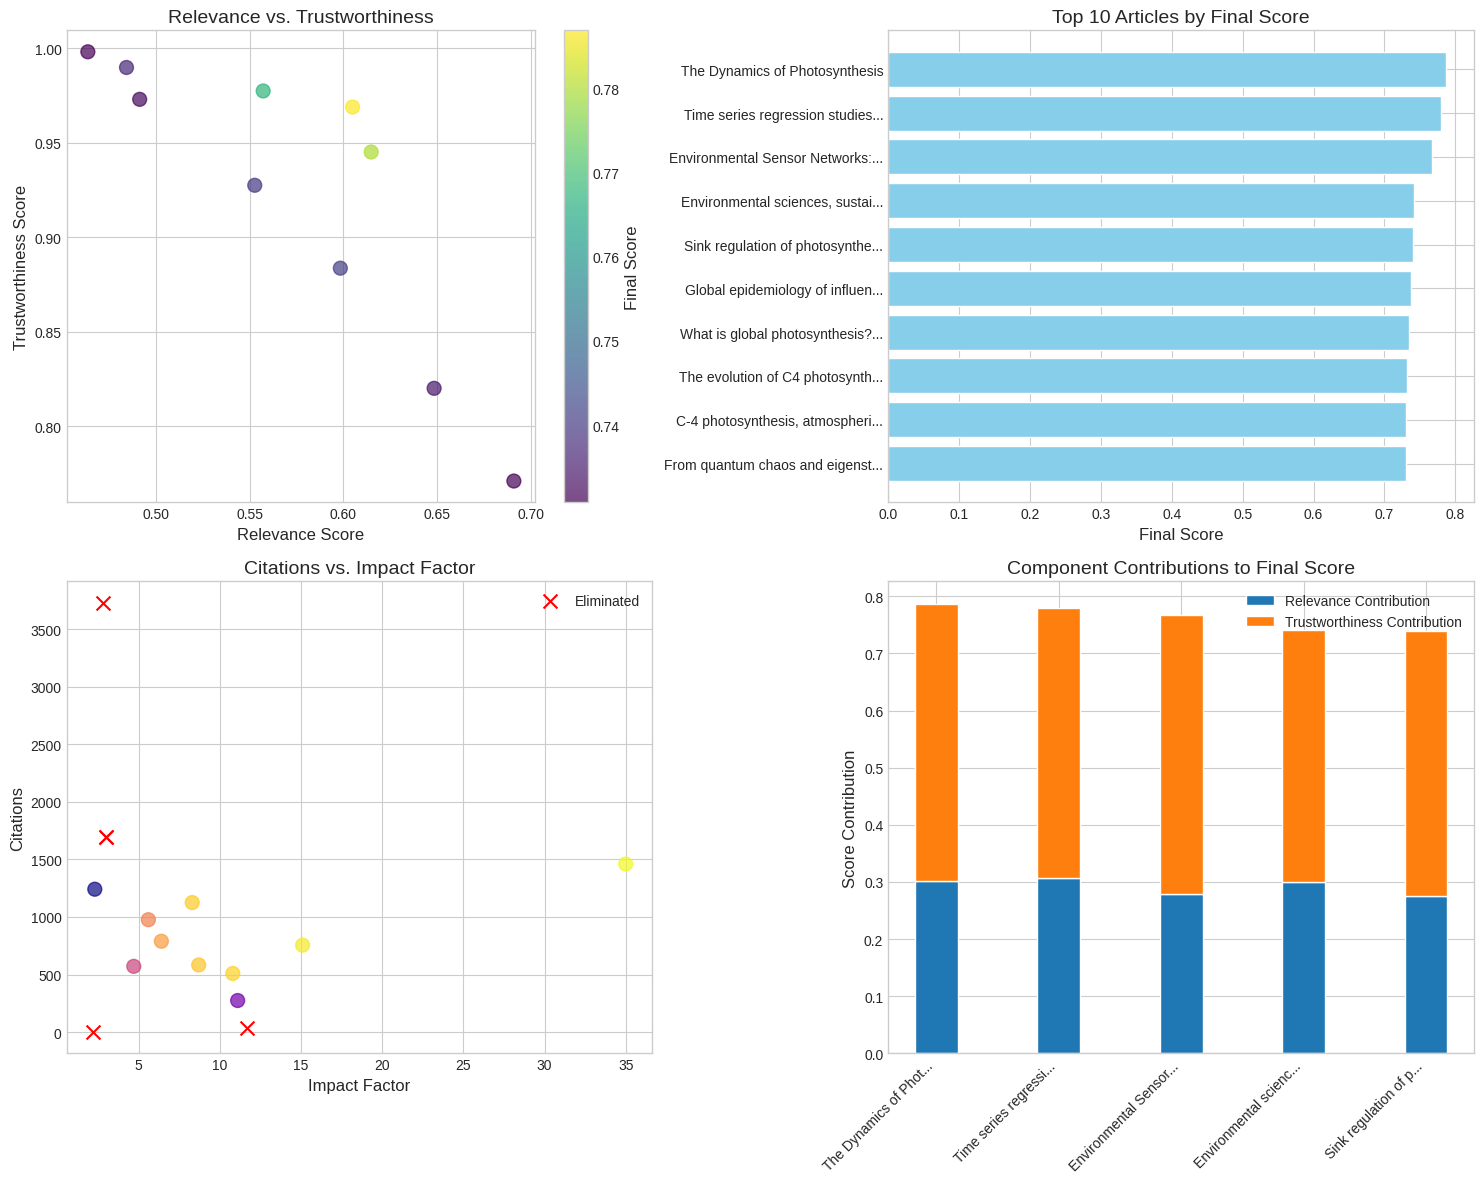

In [ ]:
# =========================================
# Step 7: Run the complete system with user input
# =========================================

# Example queries
example_queries = [
    "coronaviruses",
    "climate change effects",
    "quantum computing advancements"
]

user_query = "climate change effects"

# Run the search
ranked_results, eliminated_examples = search_academic_articles(
    query=user_query,
    top_k=10,
    alpha=0.5
)

# Display and visualize results
display_search_results(ranked_results, eliminated_examples)
visualize_search_results(ranked_results, eliminated_examples)